<a href="https://colab.research.google.com/github/andrehochuli/teaching/blob/main/%5BESPEC%5D%20Fundamentos%20Aprendizagem%20M%C3%A1quina/T%C3%B3pico%2005%20-%20Redes%20Neurais%20Artificiais/Topico_05_Aprendizado_Supervisionado_Perceptron-NOTAS-AULAS-13062026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Perceptron

Neste notebook, implementaremos o Perceptron, um modelo simples de neurônio artificial criado em 1958 por Frank Rosenblatt. Ele é capaz de classificar exemplos em duas classes e usa pesos e bias para calcular a saída final. O ajuste dos pesos e bias é dado com base nos erros de classificação em cada iteração.

O Perceptron é base para desenvolvimento de modelos mais sofisticados como o Multilayer Perceptron (MLP) e o Convolutional Neural Network (CNN). Portanto, o estudo do Perceptron é fundamental para entender as redes neurais em geral, bem como as possibilidades e limitações que elas apresentam.

É importante ressaltar que este notebook é complementar aos slides de sala de aula, os quais apresentam a teoria detalhada do Perceptron.

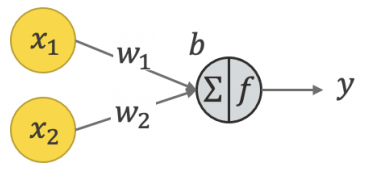

In [34]:
import numpy as np

def activation(x):
  return np.where(x >= 0, 1, 0)

def predict(X,weights,bias):
      z = np.dot(X, weights) + bias
      return activation(z)

def fit(X, y, learning_rate=0.001, epochs=100):
      n_features = X.shape[1]

      # Inicialização dos pesos
      weights = np.random.rand(n_features)
      bias = 0

      # Iteração por epocas
      for epoch in range(epochs):
          # iteração entre as amostras
          for i in range(len(X)):
              z = np.dot(X, weights) + bias # Produto escalar e bias
              y_pred = activation(z) #Função de ativação
              loss = (y[i] - y_pred[i]) #calculo da perda

              #Atualização dos pesos com base no erro
              weights = weights + learning_rate * loss * X[i]
              bias = bias + learning_rate * loss

          #Calculo de performance da epoca
          y_pred = predict(X,weights,bias)
          acc = 1 - np.sum(np.abs(y_pred-y))/len(X)
          #print(f'acc training after epcoch {epoch}: {acc}')
          print(f'Epoch{epoch}: {acc:.3f}, weights: {weights}')
      return weights, bias

Vamos testar um perceptron para determinar quando um aluno passa por média ou reprova (1) e reprovados (0).

Neste caso hipotético, criamos um dataset que representa 3 notas de um aluno, sendo a classe 1 para aqueles que atingiram média e 0 para os reprovados



In [51]:
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

np.random.seed(42)

# X_train: 300 alunos, 3 notas cada
#X = np.random.uniform(0, 10, size=(300, 3))
X = np.random.normal(loc=7, scale=1.5, size=(3000, 7))
X = np.clip(X, 0, 10)
X = np.round(X, 1)

X = np.round(X, 1)

random.shuffle(X)

# y_train: 1 se média >= 7, senão 0
medias = np.mean(X, axis=1)
y = (medias >= 7).astype(int)

X_train, X_teste, y_train, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
for i in range(20):
  print(X_train[i],y_train[i])

[7.4 5.2 8.6 7.9 5.9 4.7 6.8] 0
[8.6 7.  5.7 6.8 5.9 6.  6.8] 0
[9.  9.4 6.2 5.5 6.8 7.1 8.6] 1
[7.1 8.6 6.7 7.6 6.9 6.9 7.4] 1
[5.4 6.5 6.1 6.7 7.1 7.8 6.9] 0
[7.5 6.6 6.8 5.2 9.4 8.3 8.4] 1
[6.5 7.4 6.2 5.7 6.1 6.3 7.5] 0
[9.8 6.7 6.5 7.  6.5 8.2 4.6] 1
[7.8 6.3 8.1 4.5 6.6 7.9 8.1] 1
[7.  7.5 7.  5.8 8.2 7.3 7. ] 1
[5.7 8.2 4.2 8.  5.4 8.9 7.2] 0
[4.4 6.2 5.5 7.5 5.6 4.9 9.2] 0
[3.3 7.8 9.3 7.2 5.5 6.2 9.7] 1
[9.3 5.6 8.9 7.5 4.3 8.  6.8] 1
[4.9 8.6 6.6 8.9 7.7 5.2 9.1] 1
[4.8 7.7 8.3 7.3 8.7 6.9 6.9] 1
[ 7.6  6.7  8.5  8.8 10.   7.9  7.5] 1
[7.6 7.  8.7 6.9 4.3 8.9 5.6] 0
[5.4 7.8 8.8 8.1 8.5 5.9 4.9] 1
[4.4 6.2 5.5 7.5 5.6 4.9 9.2] 0


Vamos testar alguns exemplos de médias para ver como o modelos se comporta!

In [54]:
w,b = fit(X_train, y_train,
          learning_rate=0.001,
          epochs=200)

Epoch0: 0.497, weights: [ 0.02120691  0.02437072  0.00948803 -0.00596262 -0.00117604 -0.00794505
  0.01424318]
Epoch1: 0.497, weights: [ 0.01430691  0.03247072  0.00858803 -0.00226262  0.00422396  0.00045495
  0.01344318]
Epoch2: 0.497, weights: [ 0.01480691  0.02697072  0.02078803 -0.00396262 -0.00107604  0.00445495
  0.01324318]
Epoch3: 0.497, weights: [ 0.01330691  0.03297072  0.01528803  0.00553738 -0.00487604  0.00725495
  0.01914318]
Epoch4: 0.774, weights: [0.01120691 0.01207072 0.01448803 0.00303738 0.00132396 0.00205495
 0.01204318]
Epoch5: 0.497, weights: [0.01790691 0.02207072 0.02248803 0.00603738 0.00992396 0.01405495
 0.01574318]
Epoch6: 0.502, weights: [0.02560691 0.02377072 0.01608803 0.00853738 0.00222396 0.00495495
 0.01664318]
Epoch7: 0.497, weights: [0.01680691 0.03347072 0.01388803 0.01103738 0.00382396 0.01375495
 0.02924318]
Epoch8: 0.515, weights: [0.01690691 0.02167072 0.01858803 0.01083738 0.01402396 0.01285495
 0.01224318]
Epoch9: 0.504, weights: [0.01600691 

In [55]:
print(w)
print(b)

[0.06440691 0.07137072 0.07128803 0.06073738 0.07102396 0.06565495
 0.07964318]
-3.5169999999997237


In [56]:
#Teste

y_pred = predict(X_teste,w,b)
for i in range(20):
  if y_pred[i] == y_teste[i]:
    print(X_teste[i],y_pred[i],y_teste[i],"[OK]")
  else:
    print(X_teste[i],y_pred[i],y_teste[i],"[ERROR]")


[6.7 7.2 8.8 5.8 7.6 6.4 7. ] 0 1 [ERROR]
[ 7.6  6.7  8.5  8.8 10.   7.9  7.5] 1 1 [OK]
[8.4 4.8 3.2 8.4 4.9 6.7 5.2] 0 0 [OK]
[6.  6.3 4.2 6.3 3.4 4.6 8.1] 0 0 [OK]
[6.9 7.4 8.4 7.8 6.7 6.7 7.8] 1 1 [OK]
[6.5 6.4 7.3 7.2 7.  7.7 8.8] 1 1 [OK]
[8.8 8.5 8.4 6.3 5.4 6.1 7.3] 1 1 [OK]
[4.4 8.6 4.2 7.4 8.3 4.8 5.6] 0 0 [OK]
[6.2 5.4 6.9 8.4 5.5 7.8 6.2] 0 0 [OK]
[5.4 7.7 6.7 8.1 7.7 6.9 5.7] 0 0 [OK]
[6.2 9.7 5.6 6.6 5.2 5.  9.3] 0 0 [OK]
[7.  8.  6.5 7.5 6.8 7.1 7.9] 1 1 [OK]
[5.4 7.8 8.8 8.1 8.5 5.9 4.9] 0 1 [ERROR]
[5.6 9.6 8.4 6.6 8.7 5.3 5.8] 0 1 [ERROR]
[8.1 7.8 5.9 8.3 4.7 4.4 5.1] 0 0 [OK]
[ 8.8  9.5  7.8  5.7 10.   6.2  6.5] 1 1 [OK]
[6.9 7.8 6.2 8.8 5.7 9.6 4.4] 0 1 [ERROR]
[5.3 6.7 7.  7.9 8.  5.9 7.1] 0 0 [OK]
[4.9 4.6 9.2 6.7 6.  8.6 6.1] 0 0 [OK]
[5.9 5.2 6.7 6.2 7.9 6.9 7.9] 0 0 [OK]


In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85       296
           1       1.00      0.66      0.80       304

    accuracy                           0.83       600
   macro avg       0.87      0.83      0.83       600
weighted avg       0.87      0.83      0.83       600



Vamos visualizar as distruibuições das notas para verificar o que pode estar acontendo?

*   Poucos dados = Overfitting/UnderFitting
*   Drift na Distribuição (Treino != Teste)



E com um dataset mais robusto. Vamos criar uma rotina para determinar aleatóriamente notas. Vamos analisar diferentes montantes, ok?

In [ ]:
#criar rotina


#split do dataset


#treino

In [ ]:
#test (predict)

In [ ]:
#visualização dos dados

E com um dataset real?

Iris Dataset